In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Simulate 60 days of defect data
np.random.seed(42)
days = pd.date_range(start='2024-01-01', periods=60)
sample_size = np.random.randint(80, 120, size=60) # daily sample sizes
true_defect_rate = 0.05

# Simulate daily defect counts
defect_count = np.random.binomial(sample_size, true_defect_rate)

df = pd.DataFrame({
    'Date': days,
    'Sample_Size': sample_size,
    'Defects': defect_count
})

df['Defect_Rate'] = df['Defects'] / df ['Sample_Size']
print(df.head())

        Date  Sample_Size  Defects  Defect_Rate
0 2024-01-01          118        5     0.042373
1 2024-01-02          108        9     0.083333
2 2024-01-03           94        6     0.063830
3 2024-01-04           87        3     0.034483
4 2024-01-05          100        5     0.050000


In [3]:
#Overall average defect rate (p)
p_bar = df ['Defects'].sum() / df ['Sample_Size'].sum()

#Control Limits (30)
df['p_bar'] = p_bar
df ['UCL'] = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) /df ['Sample_Size'])
df ['LCL'] = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) / df['Sample_Size'])
df['LCL'] = df['LCL'].clip(lower=0) # LCL can't be negative

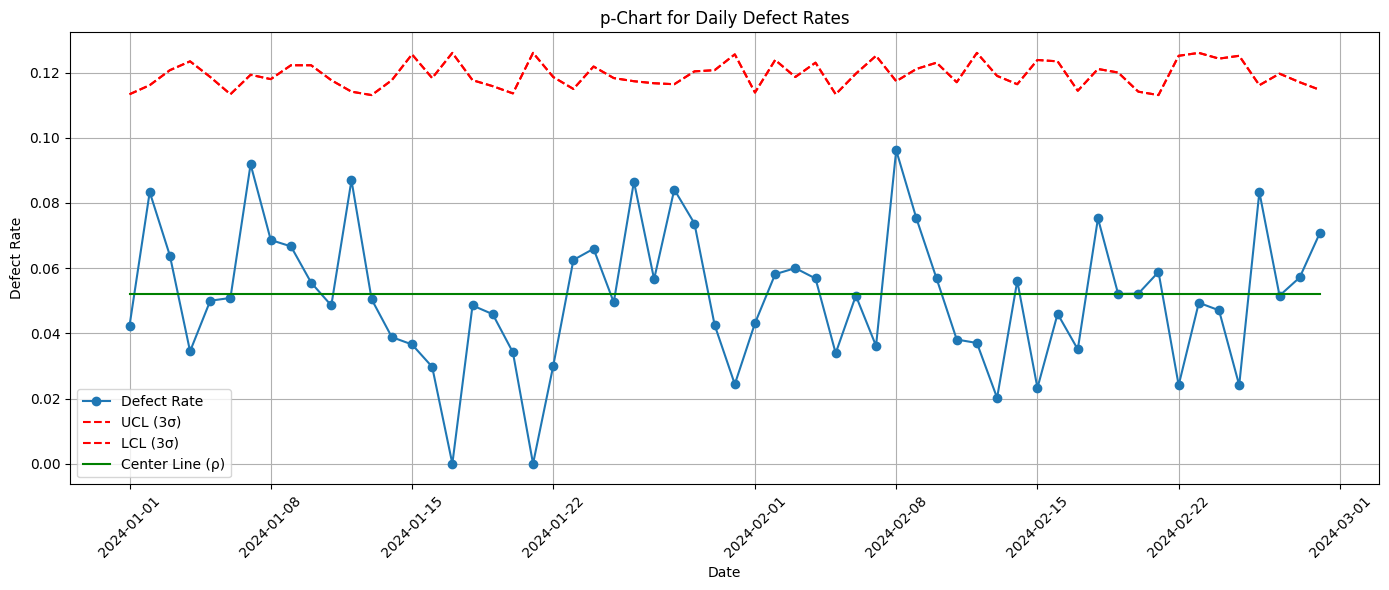

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df ['Date'], df ['Defect_Rate'], marker='o', label='Defect Rate')
plt.plot(df ['Date'], df ['UCL'], linestyle="--", color="red", label='UCL (3σ)')
plt.plot(df ['Date'], df ['LCL'], linestyle="--", color='red', label='LCL (3σ)')
plt.plot(df['Date'], df['p_bar'], linestyle='-', color='green', label='Center Line (ρ)')
plt.title('p-Chart for Daily Defect Rates')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks (rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
df['Out_of_Control'] = (df['Defect_Rate'] > df ['UCL']) | (df ['Defect_Rate'] < df ['LCL'])

# Show flagged days

print(df [df ['Out_of_Control']][['Date', 'Defect_Rate', 'UCL', 'LCL']])

         Date  Defect_Rate       UCL       LCL
0  2024-01-01     0.042373  0.113336  0.113336
1  2024-01-02     0.083333  0.116112  0.116112
2  2024-01-03     0.063830  0.120720  0.120720
3  2024-01-04     0.034483  0.123430  0.123430
4  2024-01-05     0.050000  0.118626  0.118626
5  2024-01-06     0.050847  0.113336  0.113336
6  2024-01-07     0.091837  0.119303  0.119303
7  2024-01-08     0.068627  0.117970  0.117970
8  2024-01-09     0.066667  0.122230  0.122230
9  2024-01-10     0.055556  0.122230  0.122230
10 2024-01-11     0.048544  0.117649  0.117649
11 2024-01-12     0.086957  0.114130  0.114130
12 2024-01-13     0.050420  0.113077  0.113077
13 2024-01-14     0.038835  0.117649  0.117649
14 2024-01-15     0.036585  0.125575  0.125575
15 2024-01-16     0.029703  0.118296  0.118296
16 2024-01-17     0.000000  0.126028  0.126028
17 2024-01-18     0.048544  0.117649  0.117649
18 2024-01-19     0.045872  0.115817  0.115817
19 2024-01-20     0.034188  0.113597  0.113597
20 2024-01-21

In [6]:
from statsmodels.stats.proportion import proportions_ztest

#Test if lost day's defect rate is significantly higher than average
last = df.iloc[-1]
count = last['Defects']
nobs = last['Sample_Size']

stat, pval = proportions_ztest(count, nobs, value=p_bar, alternative='larger')
print(f"Z-stat: {stat:.2f}, p-value: {pval:.4f}")

if pval < 0.05:
    print(" Statistically significant increase in defects!")

else:
    print(" No significant shift detected.")

Z-stat: 0.78, p-value: 0.2181
 No significant shift detected.


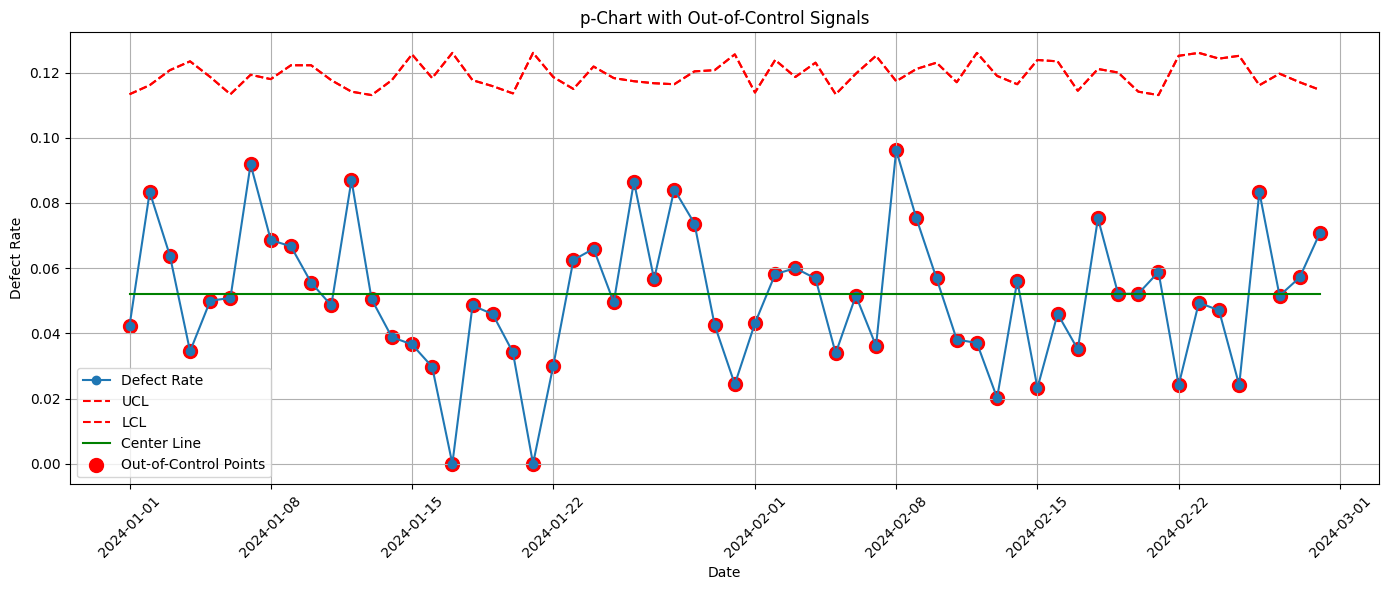

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df ['Date'], df ['Defect_Rate'], marker='o', label='Defect Rate')
plt.plot(df ['Date'], df ['UCL'], linestyle="--", color="red", label='UCL')
plt.plot(df ['Date'], df ['LCL'], linestyle="--", color='red', label='LCL')
plt.plot(df['Date'], df['p_bar'], linestyle='-', color='green', label='Center Line')

out = df[df['Out_of_Control']]
plt.scatter(out['Date'], out['Defect_Rate'], color='red', s=100, label='Out-of-Control Points')

plt.title('p-Chart with Out-of-Control Signals')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks (rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
#Introduce a shift in the defect rate on day 35
df.loc[35:, 'Defects'] = np.random.binomial(df.loc [35:, 'Sample_Size'], 0.10) #doubled defect rate
df['Defect_Rate'] = df ['Defects'] / df ['Sample_Size']

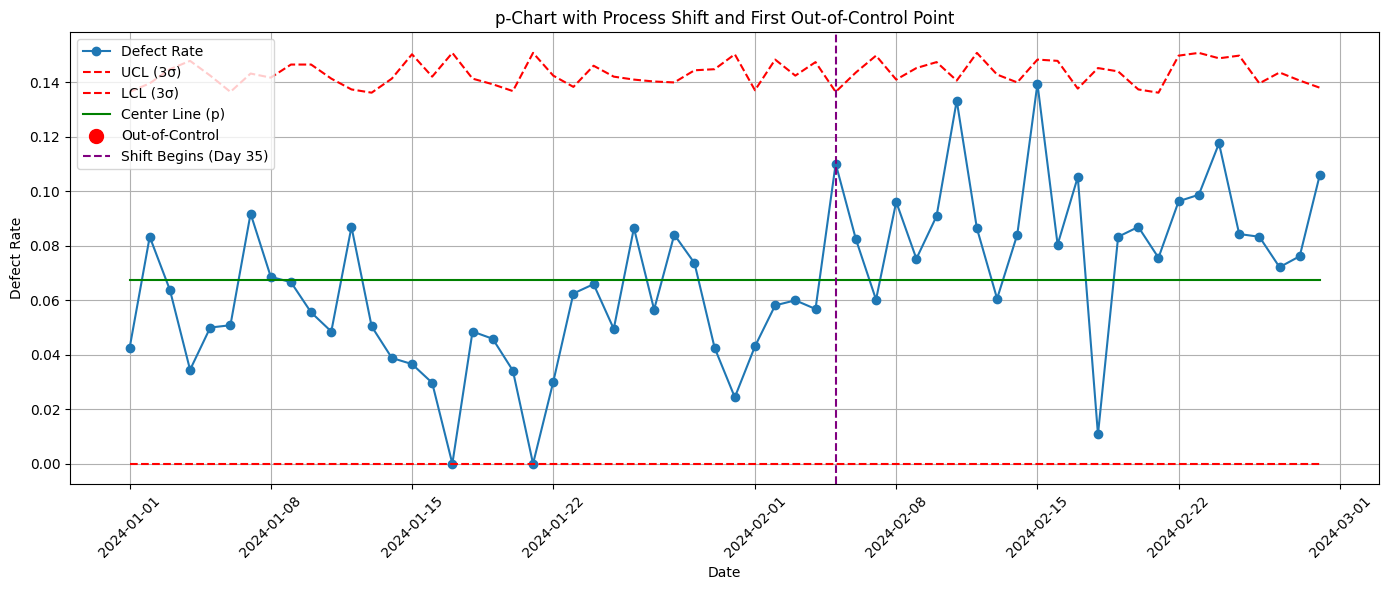

In [9]:
import matplotlib.pyplot as plt

#Recalculate p and control Limits
p_bar = df ['Defects'].sum() / df ['Sample_Size'].sum()
df['p_bar'] = p_bar
df['UCL'] = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) / df ['Sample_Size'])
df['LCL'] = p_bar - 3 * np.sqrt((p_bar * (1 - p_bar)) / df ['Sample_Size'])
df['LCL'] = df['LCL'].clip(lower=0)

#Flag out-of-control points
df['Out_of_Control'] = (df['Defect_Rate'] > df ['UCL']) | (df ['Defect_Rate'] < df ['LCL'])
out_points = df[df ['Out_of_Control']]

#Identify first out-of-control point AFTER the shift
first_shift_index = 35
first_out_after_shift = df.loc[first_shift_index:].query("Out_of_Control").head(1)

#Plot setup
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], marker='o', label='Defect Rate')
plt.plot(df['Date'], df['UCL'], linestyle='--', color='red', label='UCL (3σ)')
plt.plot(df['Date'], df['LCL'], linestyle='--', color='red', label='LCL (3σ)')
plt.plot(df['Date'], df['p_bar'], linestyle='-', color='green', label='Center Line (p)')
plt.scatter(out_points['Date'], out_points['Defect_Rate'], color='red', s=100, zorder=5, label='Out-of-Control')
plt.axvline(df['Date'].iloc[first_shift_index], color='purple', linestyle='--', label='Shift Begins (Day 35)')

#Add annotation to first out-of-control point after shift
if not first_out_after_shift.empty:
    x= first_out_after_shift['Date'].values[0]
    y= first_out_after_shift['Defect_Rate'].values[0]
    plt.annotate(
        'First out-of-control',
        xy=(x, y),
        xytext=(x, y+ 0.02),
        arrowprops=dict(facecolor='black', shrink=0.05),
        fontsize=10,
        ha='center'
    )

#Labels and Layout
plt.title('p-Chart with Process Shift and First Out-of-Control Point')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# Step 1: Estimate standard deviation for each row
df['sigma'] = np.sqrt((df['p_bar'] * (1 - df['p_bar'])) / df['Sample_Size'])

# Step 2: Compute 1σ and 2σ boundaries
df['Upper_1sigma'] = df['p_bar'] + df['sigma']
df['Lower_1sigma'] = df['p_bar'] - df['sigma']
df['Upper_2sigma'] = df['p_bar'] + 2 * df['sigma']
df['Lower_2sigma'] = df['p_bar'] - 2 * df['sigma']

# -----------------------------------------
# RULE 1: One point beyond UCL or LCL
df['Rule1'] = (df['Defect_Rate'])
#-----------------------------------------

#RULE 2 :
rule2_flags = [False] * len(df)
for i in range(2, len(df)):
    upper = (df.loc[i-2:i, 'Defect_Rate'] > df.loc[i-2:i, 'Upper_2sigma']).sum()
    lower = (df.loc[i-2:i, 'Defect_Rate'] < df.loc[i-2:i, 'Lower_2sigma']).sum()
    rule2_flags[i] = (upper >= 2) or (lower >= 2)
df['Rule2'] = rule2_flags
df['Above_Center'] = df['Defect_Rate'] > df['p_bar']
run_lengths = [1]
for i in range(1, len(df)):
    if df.loc[i, 'Above_Center'] == df.loc[i - 1, 'Above_Center']:
        run_lengths.append(run_lengths[-1] + 1)
    else:
        run_lengths.append(1)
df['Run_Length'] = run_lengths
df['Rule4'] = df['Run_Length'] >= 8

#------------------------------------
# combine rules
df['Any_Rule_Violation'] = df[['Rule1', 'Rule2', 'Rule4']].any(axis=1)
# View violations
violations = df[df['Any_Rule_Violation']]
print(violations[['Date', 'Defect_Rate', 'Rule1', 'Rule2', 'Rule4']])

               

         Date  Defect_Rate     Rule1  Rule2  Rule4
0  2024-01-01     0.042373  0.042373  False  False
1  2024-01-02     0.083333  0.083333  False  False
2  2024-01-03     0.063830  0.063830  False  False
3  2024-01-04     0.034483  0.034483  False  False
4  2024-01-05     0.050000  0.050000  False  False
5  2024-01-06     0.050847  0.050847  False  False
6  2024-01-07     0.091837  0.091837  False  False
7  2024-01-08     0.068627  0.068627  False  False
8  2024-01-09     0.066667  0.066667  False  False
9  2024-01-10     0.055556  0.055556  False  False
10 2024-01-11     0.048544  0.048544  False  False
11 2024-01-12     0.086957  0.086957  False  False
12 2024-01-13     0.050420  0.050420  False  False
13 2024-01-14     0.038835  0.038835  False  False
14 2024-01-15     0.036585  0.036585  False  False
15 2024-01-16     0.029703  0.029703  False  False
17 2024-01-18     0.048544  0.048544  False  False
18 2024-01-19     0.045872  0.045872  False  False
19 2024-01-20     0.034188  0.0

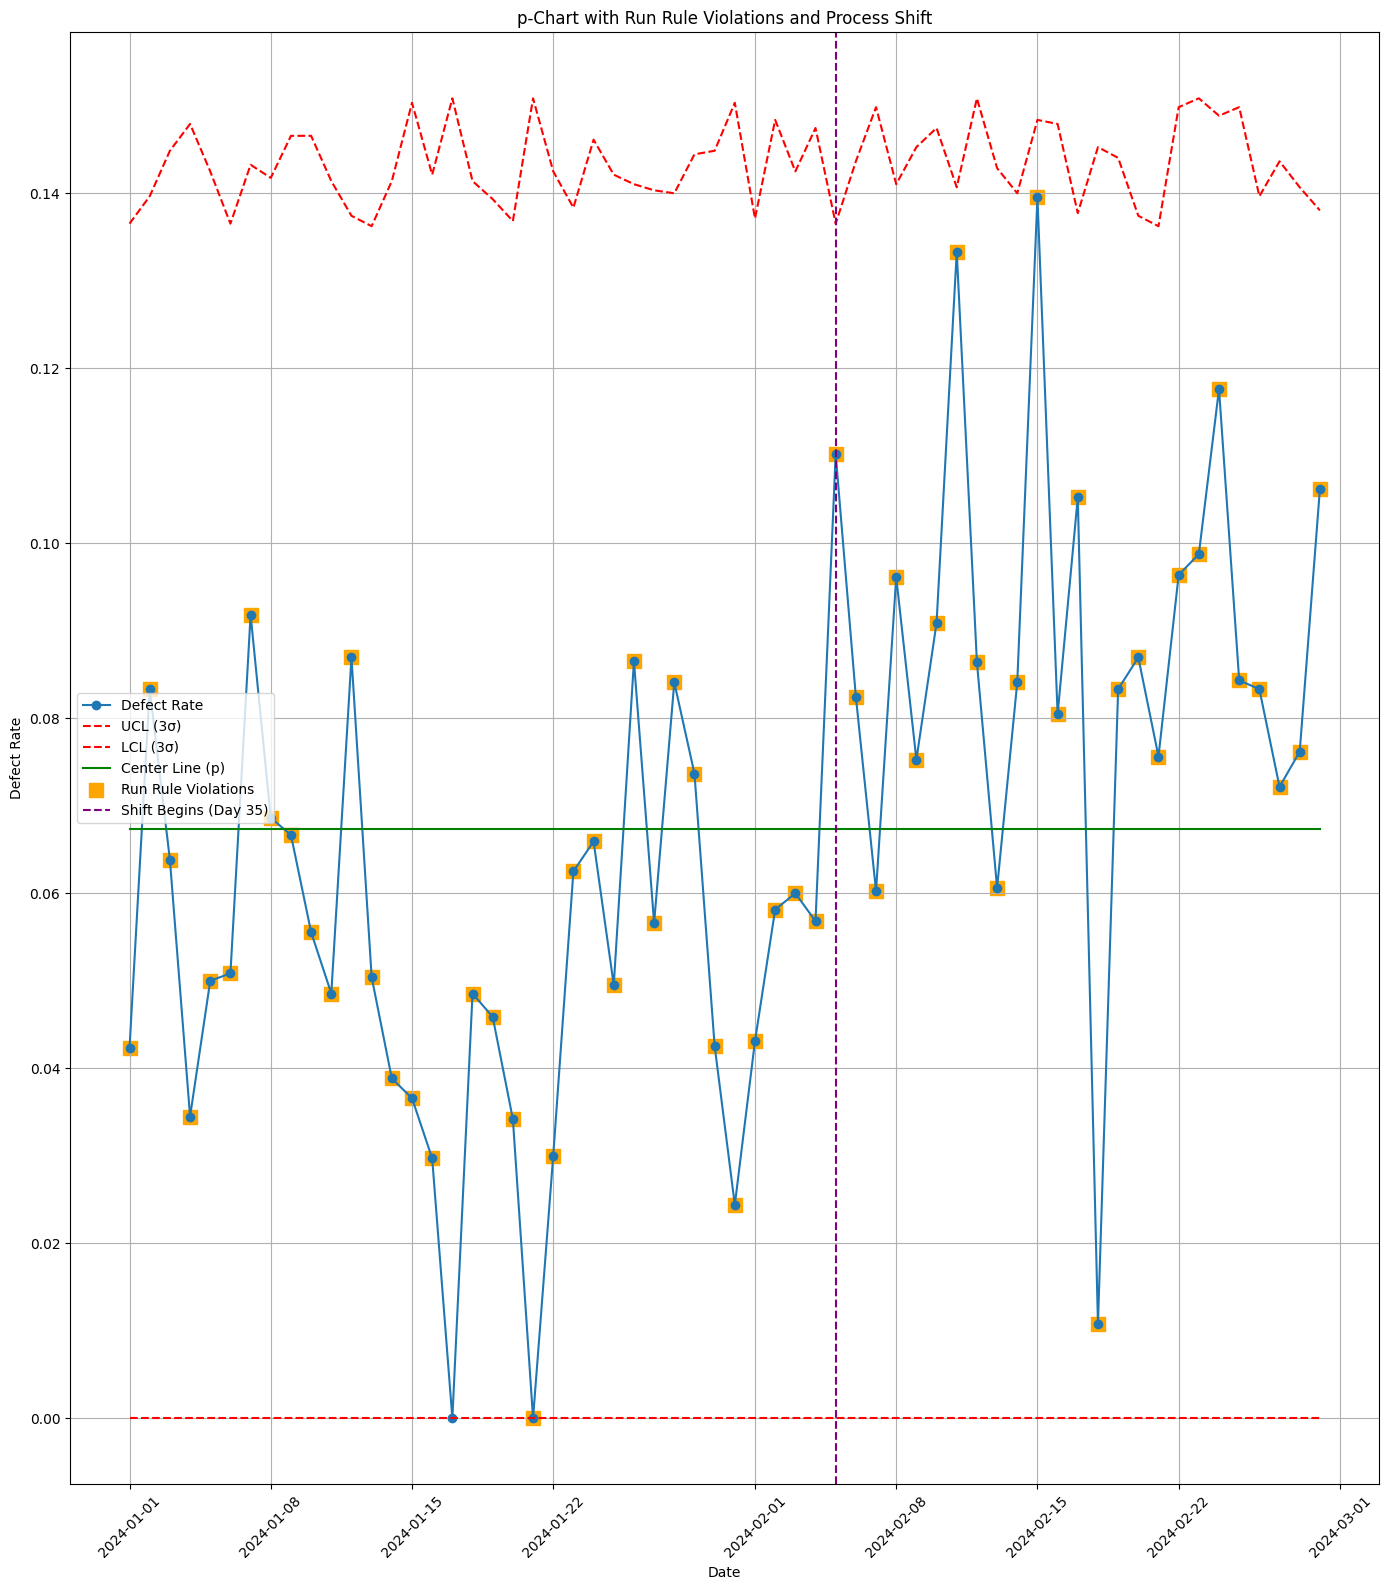

In [11]:
# plot the violatios highlighted
plt.figure(figsize=(14, 16))

# Main defect rate line 
plt.plot(df['Date'], df['Defect_Rate'], marker='o', label='Defect Rate')

# Control limits and center
plt.plot(df['Date'], df['UCL'], linestyle='--', color='red', label='UCL (3σ)')
plt.plot(df['Date'], df['LCL'], linestyle='--', color='red', label='LCL (3σ)')
plt.plot(df['Date'], df['p_bar'], linestyle='-', color='green', label='Center Line (p)')

# Highlight violations
plt.scatter(violations['Date'], violations['Defect_Rate'],
            color='orange', s=100, marker='s', label='Run Rule Violations')

# Add Shift marker
plt.axvline(df['Date'].iloc[35], color='purple', linestyle='--', label='Shift Begins (Day 35)')

# Final touches
plt.title('p-Chart with Run Rule Violations and Process Shift')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Assume specs: acceptable defect rate between 2% and 8%
USL, LSL = 0.08, 0.02
process_sigma = df['Defect_Rate'].std()

cp = (USL - LSL) / (6 * process_sigma)
cpk = min((USL - p_bar), (p_bar - LSL)) / (3 * process_sigma)

print(f"Cp: {cp:.2f}, cpk: {cpk:.2f}")

Cp: 0.34, cpk: 0.14


In [13]:
boot_means = [np.mean(np.random.choice(df['Defect_Rate'], size=len(df), replace=True)) for _ in range(1000)]
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f"95% CI for average defect rate: ({ci_lower:.4f}, {ci_upper:.4f})")

95% CI for average defect rate: (0.0602, 0.0743)


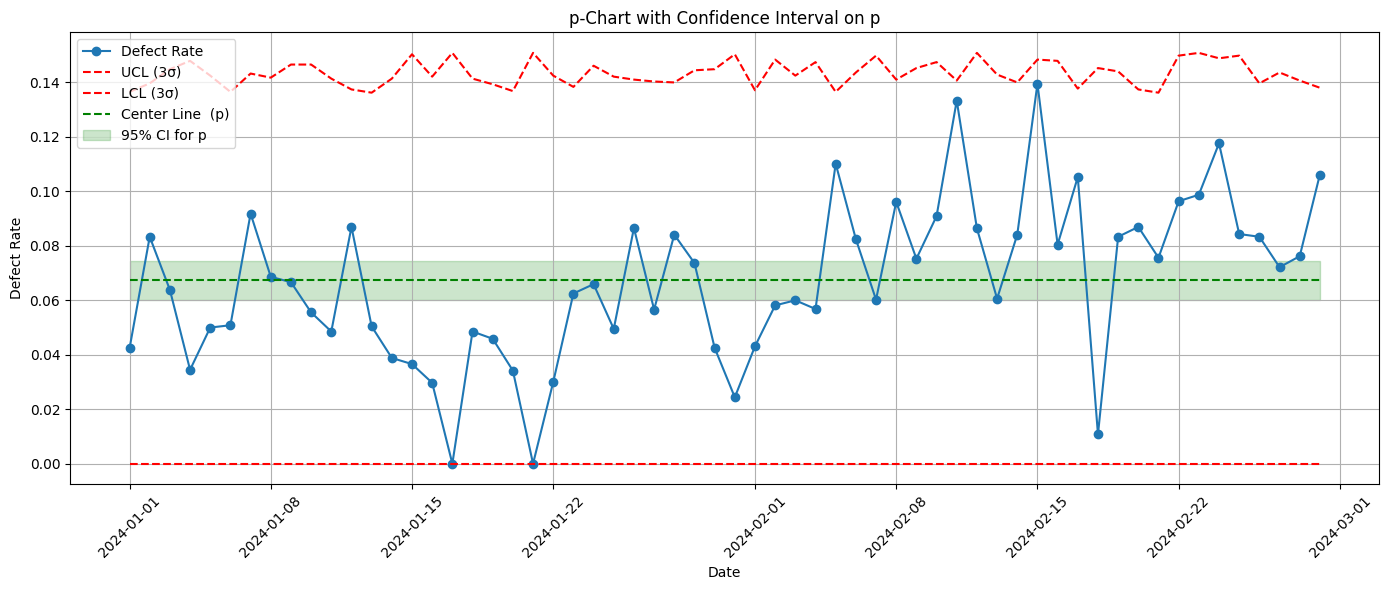

In [14]:
# Existing chart
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], marker='o', label='Defect Rate')
plt.plot(df['Date'], df['UCL'], linestyle='--', color='red', label='UCL (3σ)')
plt.plot(df['Date'], df['LCL'], linestyle='--', color='red', label='LCL (3σ)')
plt.plot(df['Date'], df['p_bar'], linestyle='--', color='green', label='Center Line  (p)')

# Add this for confidence interval shading
plt.fill_between(
    df['Date'], ci_lower, ci_upper,
    color='green', alpha=0.2, label='95% CI for p'
)

# Finalize chart
plt.title('p-Chart with Confidence Interval on p')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
         

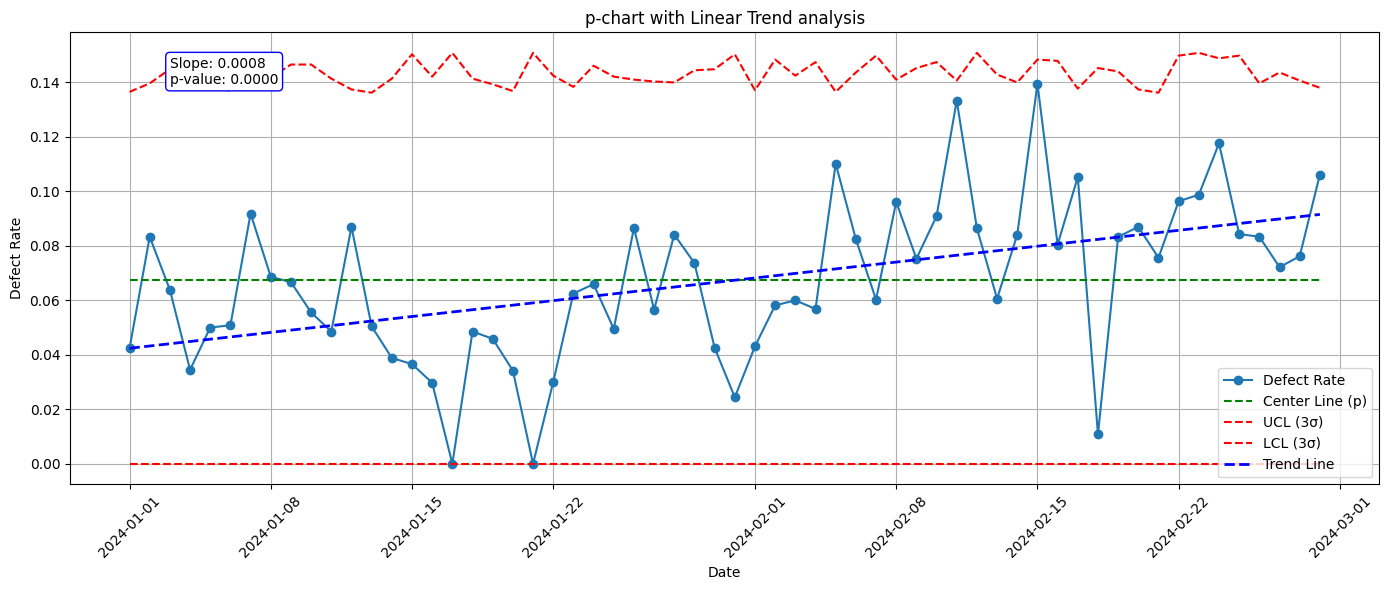

In [17]:
from scipy.stats import linregress 
import matplotlib.pyplot as plt

# Step 1 create a numeric "Day" column
df['Day'] = range(1, len(df) + 1)

# Step 2 : Run Linear regression on defect rate over time
trend_result = linregress(df['Day'], df['Defect_Rate'])

slope = trend_result.slope
p_value = trend_result.pvalue
intercept = trend_result.intercept

# step 3: Create  trend line values
df['Trend_Line'] = intercept + slope * df['Day']

# Step 4: Plot p-chart with trend line
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], marker='o', label='Defect Rate')
plt.plot(df['Date'], df['p_bar'], linestyle='--', color='green', label='Center Line (p)')
plt.plot(df['Date'], df['UCL'], linestyle='--', color='red', label='UCL (3σ)')
plt.plot(df['Date'], df['LCL'], linestyle='--', color='red', label='LCL (3σ)')

# Add trend line
plt.plot(df['Date'], df['Trend_Line'], linestyle='--', color='blue', linewidth=2, label='Trend Line')

# Step 5: Annotate with slope and p-value
plt.text(df['Date'].iloc[2], max(df['Defect_Rate']),
         f"Slope: {slope:.4f}\np-value: {p_value:.4f}",
         fontsize=10, bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round'))

# Final touches
plt.title('p-chart with Linear Trend analysis')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

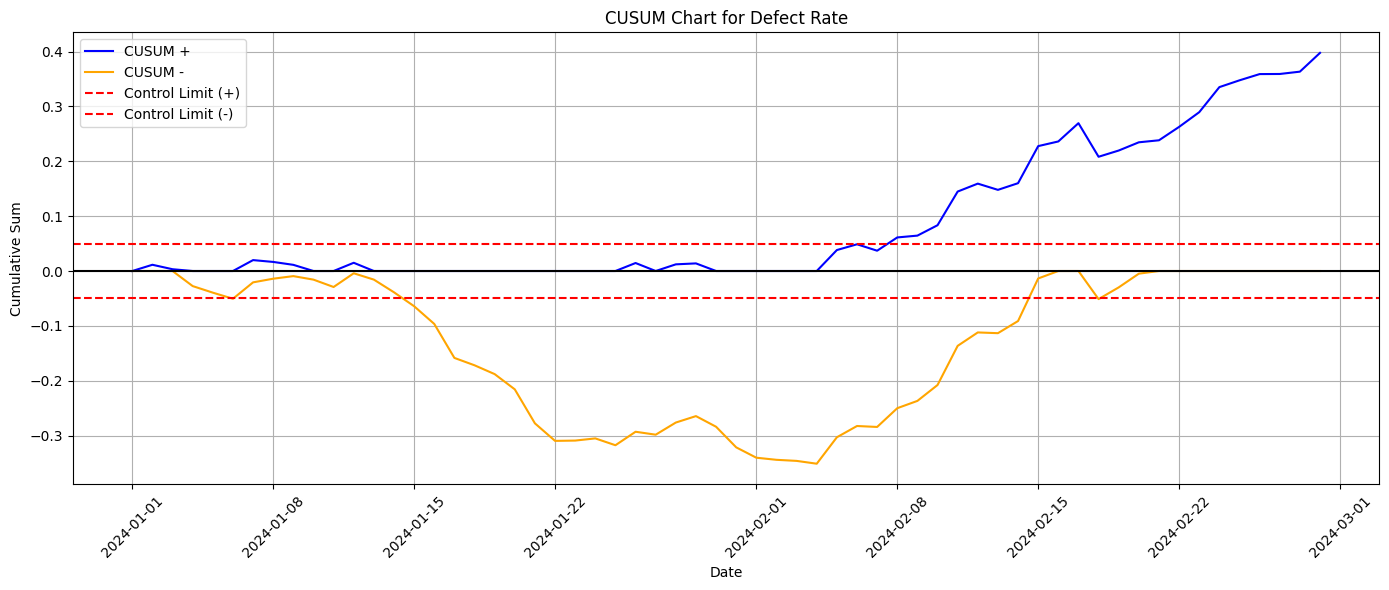

In [26]:
# CUSUM parameters
target = df['Defect_Rate' ].mean() # p
k = 0.005 # Reference value (tuning sensitivity)
h = 0.05 # Decision threshold

# Initialize lists
cusum_pos = [0]
cusum_neg = [0]

# Calculate CUSUM values
for i in range(1, len(df)):
    p_i = df.loc[i, 'Defect_Rate']
    s_pos = max(0, cusum_pos[-1] + (p_i - target - k))
    s_neg = min(0, cusum_neg[-1] + (p_i - target + k))
    cusum_pos.append(s_pos )
    cusum_neg.append(s_neg)

# Add to DataFrame
df['CUSUM_Pos'] = cusum_pos
df['CUSUM_Neg'] = cusum_neg

# PLot CUSUM
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['CUSUM_Pos'], label='CUSUM +', color='blue')
plt.plot(df['Date'], df['CUSUM_Neg'], label='CUSUM -', color='orange')
plt.axhline(h, color='red', linestyle='--', label='Control Limit (+)')
plt.axhline(-h, color='red', linestyle='--', label='Control Limit (-)')
plt.axhline(0, color='black', linestyle='-')
plt.title('CUSUM Chart for Defect Rate')
plt.xlabel('Date')
plt.ylabel('Cumulative Sum')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

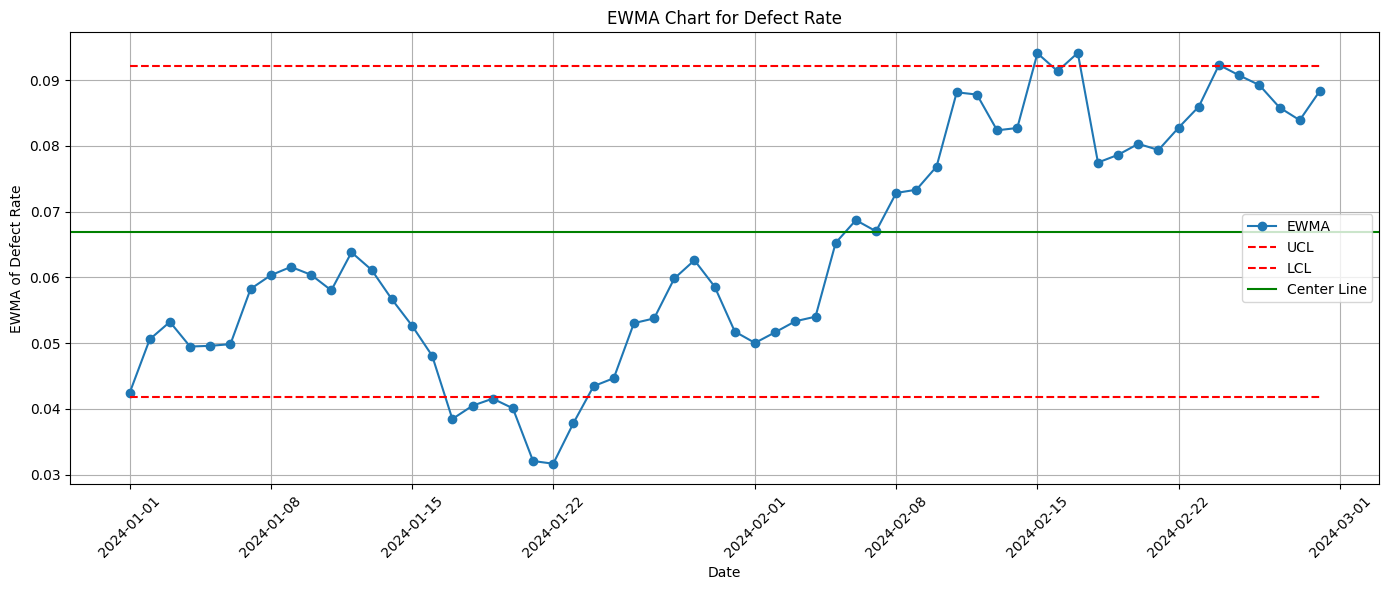

In [28]:
# EWMA parameters
lambda_ = 0.2 # Smoothing constant (0.1-0.3 common)
L = 3 # Control Limit multiplier

# Initialize EWMA
df['EWMA'] = 0.0
df.loc[0, 'EWMA'] = df. loc[0, 'Defect_Rate']

# Compute EWMA for each day
for i in range(1, len(df)):
    df.loc[i, 'EWMA'] = lambda_ * df. loc[i, 'Defect_Rate'] + (1 - lambda_) * df.loc[i - 1, 'EWMA']
    
# Estimate sigma (average over entire series)
p_bar = df['Defect_Rate'].mean()
avg_n = df['Sample_Size'].mean()
sigma = np.sqrt((p_bar * (1 - p_bar)) / avg_n)

# Control Limits
df['UCL_EWMA'] = p_bar + L * sigma * np.sqrt(lambda_ / (2 - lambda_))
df['LCL_EWMA'] = p_bar - L * sigma * np.sqrt(lambda_ / (2 - lambda_))

# PLot EWMA
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['EWMA'], marker='o', label='EWMA')
plt.plot(df['Date'], df['UCL_EWMA'], linestyle='--', color='red', label='UCL')
plt.plot(df['Date'], df['LCL_EWMA'], linestyle='--', color='red', label='LCL')
plt.axhline(p_bar, color='green', linestyle='-', label='Center Line')
plt.title('EWMA Chart for Defect Rate')
plt.xlabel('Date')
plt.ylabel('EWMA of Defect Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

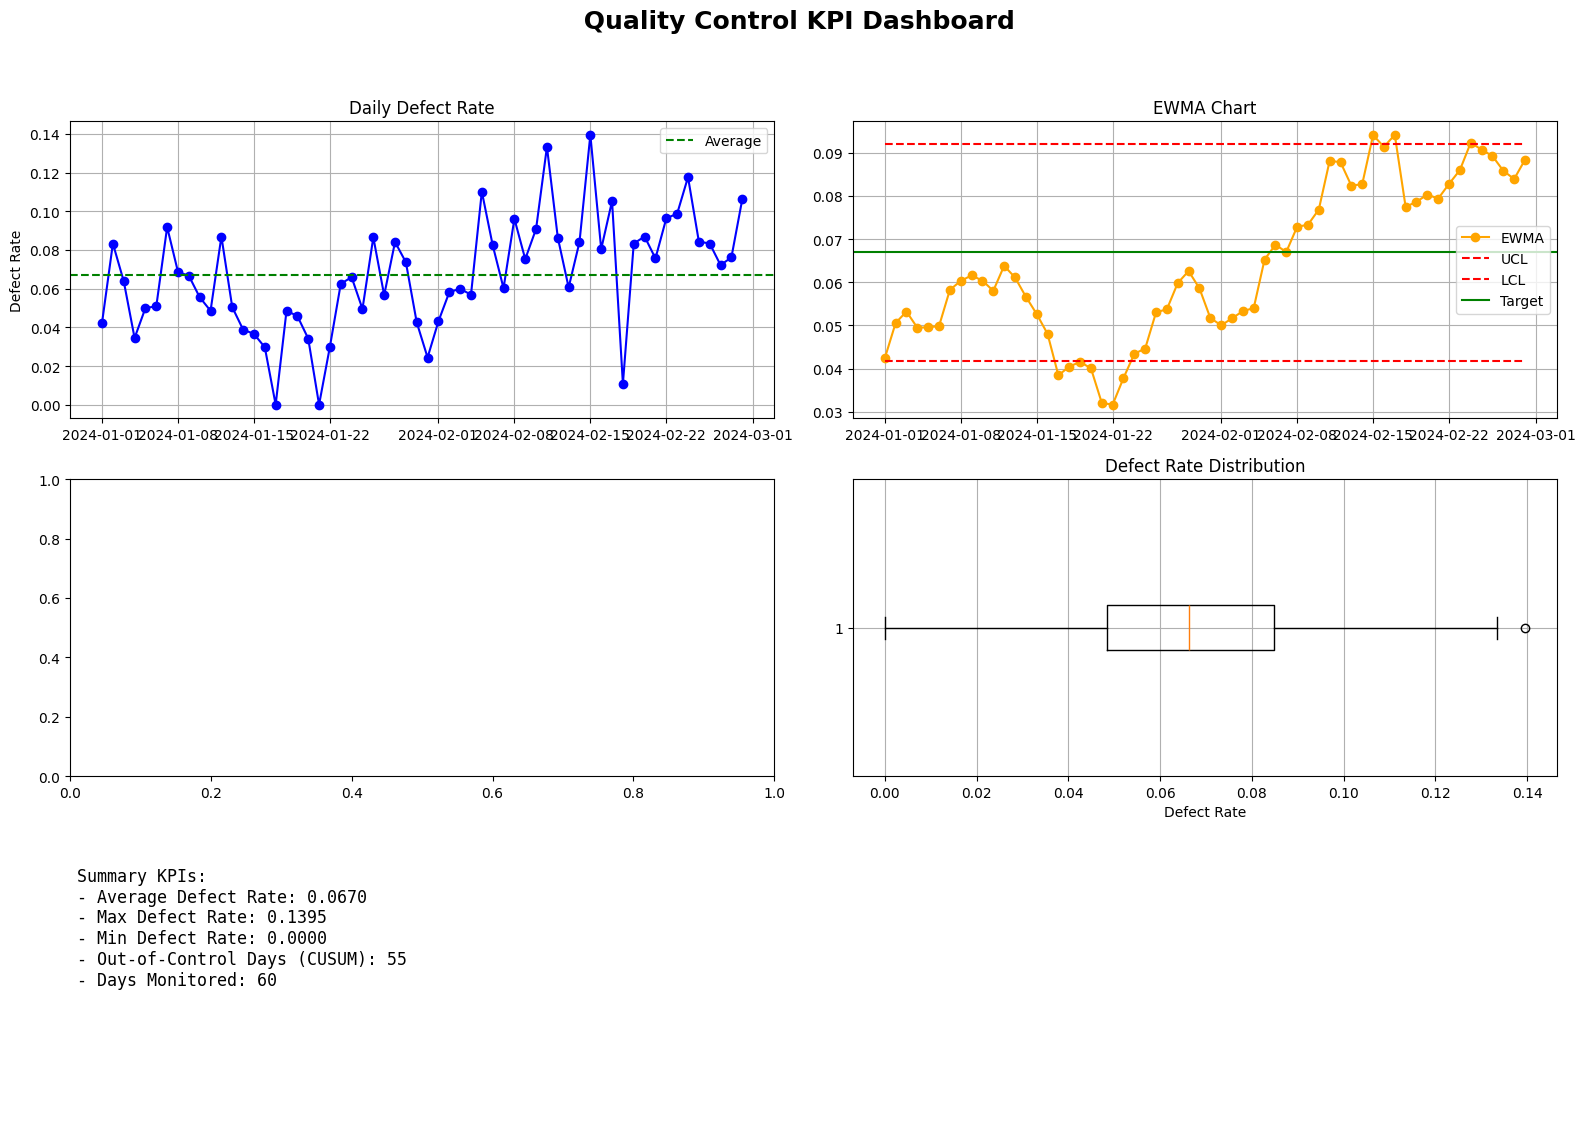

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Recalculate needed KPIs
avg_defect_rate = df['Defect_Rate'].mean()
max_defect_rate = df['Defect_Rate'].max()
min_defect_rate = df['Defect_Rate'].min()
out_of_control_days = (df['CUSUM_Pos'] > 0.05).sum() + (df['CUSUM_Neg'] < -0.05).sum()

# Create subplot grid
fig, axs = plt. subplots(3, 2, figsize=(16, 12))
fig.suptitle(' Quality Control KPI Dashboard', fontsize=18, fontweight='bold')

# --- 1. Daily Defect Rate ---
axs[0, 0].plot(df['Date'], df['Defect_Rate'], marker='o', color='blue')
axs[0, 0].axhline(avg_defect_rate, color='green', linestyle='--', label='Average')
axs[0, 0].set_title('Daily Defect Rate')
axs[0, 0].set_ylabel('Defect Rate')
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- 2. EWMA Chart---
axs[0, 1].plot(df['Date'], df['EWMA'], marker='o', label='EWMA', color='orange')
axs[0, 1].plot(df['Date'], df['UCL_EWMA'], linestyle='--', color='red', label='UCL')
axs[0, 1].plot(df['Date'], df['LCL_EWMA'], linestyle='--', color='red', label='LCL')
axs[0, 1].axhline(avg_defect_rate, color='green', linestyle='-', label='Target')
axs[0, 1].set_title('EWMA Chart')
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- 4. Boxplot of Defect Rates ---
axs[1, 1].boxplot(df['Defect_Rate'], vert=False)
axs[1, 1].set_title('Defect Rate Distribution')
axs[1, 1].set_xlabel('Defect Rate')
axs[1, 1].grid(True)

# --- 5. KPI Summary -
axs[2, 0].axis('off')

summary = (
    f"Summary KPIs:\n"
    f"- Average Defect Rate: {avg_defect_rate:.4f}\n"
    f"- Max Defect Rate: {max_defect_rate:.4f}\n"
    f"- Min Defect Rate: {min_defect_rate:.4f}\n"
    f"- Out-of-Control Days (CUSUM): {out_of_control_days}\n"
    f"- Days Monitored: {len(df)}"
)

    
axs[2, 0].text(0.01, 0.9, summary, fontsize=12, verticalalignment='top', family='monospace')
# --- 6. Empty space or add more content ---
axs[2, 1].axis('off') # Placeholder for future KPI

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [48]:
# Step 1: Estimate standard deviation for each row
df['sigma'] = np.sqrt((df['p_bar'] * (1 - df['p_bar'])) / df['Sample_Size' ])

# Step 2: Compute 1o and 2a boundaries
df['Upper_1sigma'] = df['p_bar'] + df['sigma']
df['Lower_1sigma'] = df['p_bar'] - df['sigma']
df['Upper_2sigma'] = df['p_bar'] + 2 * df['sigma']
df['Lower_2sigma'] = df['p_bar'] - 2 * df['sigma']

#...................................................
# RULE 1: One point beyond UCL or LCL
df['Rule1'] = (df['Defect_Rate'] > df['UCL']) | (df['Defect_Rate'] < df['LCL'])

#...................................................
# RULE 2: 2 of 3 consecutive points beyond 2o (same side)
rule2_flags = [False] * len(df)
for i in range(2, len(df)):
    upper = (df.loc[i-2:i, 'Defect_Rate'] > df.loc[i-2:i, 'Upper_2sigma']).sum()
    lower = (df. loc[i-2:i, 'Defect_Rate'] < df.loc[i-2:i, 'Lower_2sigma']).sum()
    rule2_flags[i] =(upper >= 2) or (lower >= 2)
    df['Rule2'] = rule2_flags

#..................................................
# RULE 4: 8 points in a row on same side of center Line
df['Above_Center'] = df['Defect_Rate'] > df['p_bar']
run_lengths = [1]
for i in range(1, len(df)):
    if df.loc[i, 'Above_Center'] == df.loc[i - 1, 'Above_Center']:
        run_lengths.append(run_lengths[-1] + 1)

